# Lesson 4: Basic Statistical Analysis with AI Assistance
## Making Data-Driven Decisions in Materials Science

**Duration**: 2 weeks (Weeks 7-8)  
**Weekly Workload**: 3 hours per week  
**Learning Focus**: Statistical analysis fundamentals with strategic AI collaboration

---

## Learning Objectives

By the end of this lesson, you will be able to:
- **Select appropriate statistical tests** for materials science data using AI assistance
- **Perform basic hypothesis testing** with proper assumption validation
- **Calculate and interpret effect sizes** for practical significance
- **Use AI strategically** for statistical interpretation and report generation
- **Critically evaluate** AI-generated statistical advice and outputs

---

## 📸 **DOCUMENTATION REQUIREMENTS**

Throughout this lesson, you'll see this icon: <span style="font-size: 1.5em;">📸</span>

**When you see 📸, take a screenshot to document your work:**
- **Windows**: Press `Windows key + Shift + S`
- **macOS**: Press `Cmd + Shift + 4`
- **Linux**: Press `PrtScn`

**Save screenshots with descriptive names:**
- `week7_data_exploration.png`
- `week7_ai_test_selection.png`
- `week7_assumption_check.png`
- `week7_test_results.png`
- `week8_effect_size.png`
- `week8_final_report.png`

---

---

## Week 7: Statistical Foundations & AI-Assisted Test Selection

**Time Allocation**: 3 hours
- Mini-Lecture: 20-25 minutes
- Dataset Introduction: 10-15 minutes
- Guided Activity 1: 45-60 minutes
- Reflection: 15-20 minutes

---

### Mini-Lecture: Statistical Thinking in Materials Science (20-25 min)

#### Why Statistics Matter in MSE

Materials science is inherently about variability:
- **Processing variations**: Heat treatment times, cooling rates, composition control
- **Measurement uncertainty**: Testing equipment precision, sample preparation
- **Material heterogeneity**: Grain size distribution, phase composition, defect density

**Key Question**: When you observe a difference between two materials or conditions, is it **real** or just **random variation**?

#### The 3-Question Framework for Statistical Analysis

Before running any statistical test, ask:

**1. What type of data do I have?**
   - Continuous (tensile strength, hardness, composition %)
   - Categorical (alloy type, heat treatment condition, pass/fail)
   - Ordinal (grain size rating: fine/medium/coarse)

**2. What question am I asking?**
   - Comparing groups (does heat treatment A differ from B?)
   - Relationships (does composition correlate with strength?)
   - Distributions (is my manufacturing process producing consistent results?)

**3. What assumptions must I check?**
   - **Normality**: Does data follow a bell curve?
   - **Independence**: Are measurements independent of each other?
   - **Homogeneity**: Do groups have similar variability?

#### AI as Your Statistical Consultant

**✅ Good uses of AI for statistics:**
- Recommending appropriate tests based on data characteristics
- Explaining statistical concepts in materials science context
- Generating code templates for statistical tests
- Suggesting visualizations to check assumptions

**⚠️ AI limitations to watch for:**
- May not understand your specific materials science context
- Can hallucinate p-values or test results
- Might recommend overly complex tests for simple questions
- May not catch domain-specific data quality issues

**Golden Rule**: Always validate AI statistical advice with your own critical thinking and materials science knowledge.

---

### Dataset Introduction: Materials Science Data Loading (10-15 min)

**You have two options for this lesson:**

**Option 1**: Use your dataset from Lesson 03 (recommended for continuity)
- glass.json → Compare glass-forming vs non-glass-forming compositions
- steels_yield.json → Compare high vs low yield strength groups
- matbench_expt_is_metal.json → Compare metallic vs non-metallic behavior

**Option 2**: Use the new heat treatment dataset provided below
- Aluminum alloy heat-treated under different conditions
- Compare hardness between two heat treatment protocols

**Instructions:**
1. Choose your dataset option
2. Uncomment the appropriate code section below
3. Run the cell to load your data
4. You'll use this same dataset for both Week 7 and Week 8

---

In [7]:
# === Dataset Loading ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# ============================================================================
# OPTION 1: Use your Lesson 03 dataset (RECOMMENDED)
# ============================================================================

# # Option 1A: Glass formation dataset
# import json
# with open('../data_files/database/glass.json', 'r') as f:
#     glass_data = json.load(f)
# compositions = [item[0] for item in glass_data['data']]
# glass_forming = [item[1] for item in glass_data['data']]
# data = pd.DataFrame({'Composition': compositions, 'Glass_Forming': glass_forming})
# data['Complexity'] = data['Composition'].str.len()
# group_col = 'Glass_Forming'
# value_col = 'Complexity'
# dataset_name = "Metallic Glass Formation Database"
# research_question = "Do glass-forming compositions have different complexity?"

# # Option 1B: Steel yield strength dataset  
# import json
# with open('../data_files/database/steels_yield.json', 'r') as f:
#     steel_data = json.load(f)
# compositions = [item[0] for item in steel_data['data']]
# yield_strengths = [item[1] for item in steel_data['data']]
# data = pd.DataFrame({'composition': compositions, 'yield_strength_MPa': yield_strengths})
# median_strength = data['yield_strength_MPa'].median()
# data['Strength_Category'] = data['yield_strength_MPa'].apply(
#     lambda x: 'High_Strength' if x >= median_strength else 'Standard_Strength'
# )
# group_col = 'Strength_Category'
# value_col = 'yield_strength_MPa'
# dataset_name = "Steel Yield Strength Database"
# research_question = "Difference between high and standard strength steels?"

# # Option 1C: Metal classification dataset
# import json
# with open('../data_files/database/matbench_expt_is_metal.json', 'r') as f:
#     metal_data = json.load(f)
# compositions = [item[0] for item in metal_data['data']]
# is_metal = [item[1] for item in metal_data['data']]
# data = pd.DataFrame({'composition': compositions, 'is_metal': is_metal})
# import re
# data['num_elements'] = data['composition'].apply(lambda x: len(re.findall(r'[A-Z][a-z]?', x)))
# group_col = 'is_metal'
# value_col = 'num_elements'
# dataset_name = "Metal Classification Database"
# research_question = "Compositional complexity difference by metal type?"

# ============================================================================
# OPTION 2: Heat Treatment Dataset (NEW)
# ============================================================================

# Generate realistic aluminum alloy heat treatment data
np.random.seed(42)
n_samples = 30

# Treatment A: Standard T6 (160°C, 18 hours)
treatment_a = np.random.normal(150, 8, n_samples)

# Treatment B: Modified T6 (180°C, 12 hours)
treatment_b = np.random.normal(165, 7, n_samples)

# Create DataFrame
data = pd.DataFrame({
    'Sample_ID': range(1, 2*n_samples + 1),
    'Treatment': ['Standard_T6']*n_samples + ['Modified_T6']*n_samples,
    'Hardness_HV': np.concatenate([treatment_a, treatment_b]),
    'Temperature_C': [160]*n_samples + [180]*n_samples,
    'Time_hours': [18]*n_samples + [12]*n_samples
})

group_col = 'Treatment'
value_col = 'Hardness_HV'
dataset_name = "Aluminum Alloy Heat Treatment Study"
research_question = "Does modified T6 produce different hardness than standard T6?"

# Display loaded data
print("="*70)
print(f"DATASET LOADED: {dataset_name}")
print("="*70)
print(f"\nResearch Question: {research_question}")
print(f"\nDataset Shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
print(f"\nGrouping Variable: {group_col}")
print(f"Value Variable: {value_col}")
print(f"\nFirst 5 rows:")
print(data.head())
print(f"\nLast 5 rows:")
print(data.tail())

DATASET LOADED: Aluminum Alloy Heat Treatment Study

Research Question: Does modified T6 produce different hardness than standard T6?

Dataset Shape: (60, 5)
Columns: ['Sample_ID', 'Treatment', 'Hardness_HV', 'Temperature_C', 'Time_hours']

Grouping Variable: Treatment
Value Variable: Hardness_HV

First 5 rows:
   Sample_ID    Treatment  Hardness_HV  Temperature_C  Time_hours
0          1  Standard_T6   153.973713            160          18
1          2  Standard_T6   148.893886            160          18
2          3  Standard_T6   155.181508            160          18
3          4  Standard_T6   162.184239            160          18
4          5  Standard_T6   148.126773            160          18

Last 5 rows:
    Sample_ID    Treatment  Hardness_HV  Temperature_C  Time_hours
55         56  Modified_T6   171.518961            180          12
56         57  Modified_T6   159.125477            180          12
57         58  Modified_T6   162.835513            180          12
58       

---

## Guided Activity 1: Data Exploration & AI-Assisted Test Selection (45-60 min)

**Learning Goal**: Before jumping into statistical tests, you need to understand your data. In this activity, you'll explore your data, consult with AI about appropriate tests, and learn to critically evaluate AI recommendations.

---

### Task 1: Exploratory Data Analysis (15 min)

**Your Task**: Complete the starter code below to explore your data.

**What you'll do:**
1. Calculate descriptive statistics for each group
2. Create visualizations to compare groups
3. Make initial observations about patterns

**Why this matters**: Understanding your data BEFORE statistical testing helps you:
- Identify obvious patterns or problems
- Spot outliers that might affect results
- Form hypotheses about what tests might be appropriate

---

In [8]:
# === Task 1: Exploratory Data Analysis (COMPLETE THE TODOs) ===

print("="*70)
print("EXPLORATORY DATA ANALYSIS")
print("="*70)

# Get unique groups
groups = data[group_col].unique()
print(f"\nGroups to compare: {groups}")

# Calculate descriptive statistics for each group
print(f"\nDescriptive Statistics for {value_col}:")
print("-" * 70)

for group in groups:
    group_data = data[data[group_col] == group][value_col].dropna()
    
    print(f"\n{group}:")
    print(f"  Sample size (n): {len(group_data)}")
    
    # TODO: Calculate and print the mean
    # HINT: Use group_data.mean()
    # print(f"  Mean: {YOUR_CODE_HERE:.3f}")
    
    # TODO: Calculate and print the median
    # HINT: Use group_data.median()
    # print(f"  Median: {YOUR_CODE_HERE:.3f}")
    
    # TODO: Calculate and print the standard deviation
    # HINT: Use group_data.std()
    # print(f"  Std Dev: {YOUR_CODE_HERE:.3f}")
    
    print(f"  Min: {group_data.min():.3f}")
    print(f"  Max: {group_data.max():.3f}")

EXPLORATORY DATA ANALYSIS

Groups to compare: ['Standard_T6' 'Modified_T6']

Descriptive Statistics for Hardness_HV:
----------------------------------------------------------------------

Standard_T6:
  Sample size (n): 30
  Min: 134.694
  Max: 162.634

Modified_T6:
  Sample size (n): 30
  Min: 151.282
  Max: 177.966


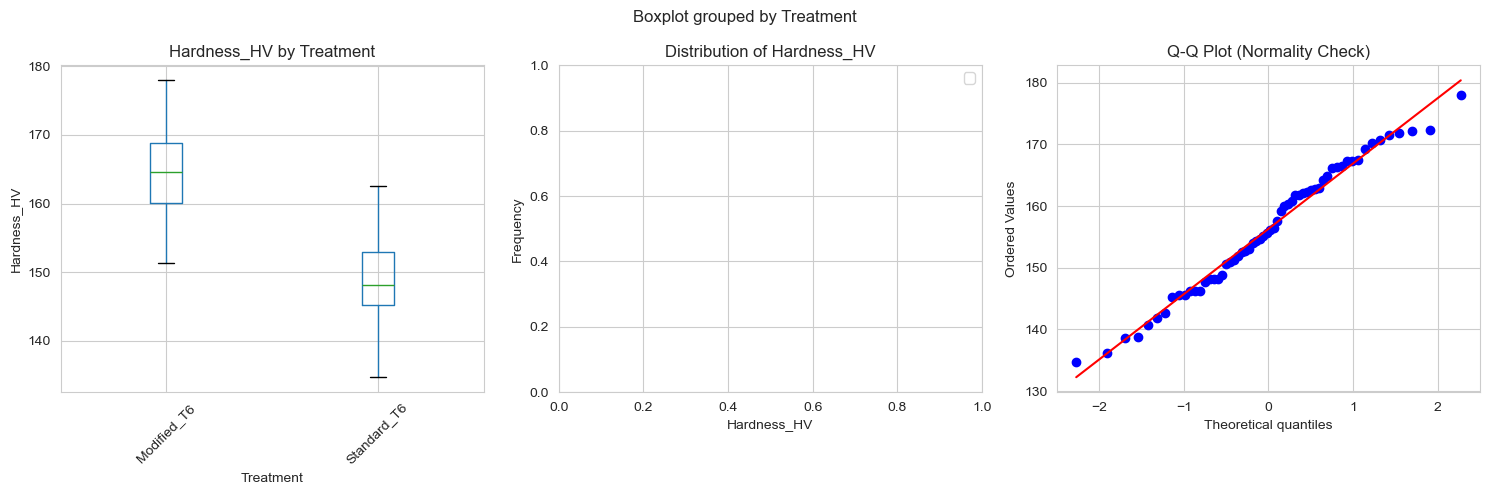


📸 SCREENSHOT REQUIRED: Save this visualization as 'week7_data_exploration.png'


In [9]:
# === Create Visualizations (COMPLETE THE TODOs) ===

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Box plot to compare distributions
data.boxplot(column=value_col, by=group_col, ax=axes[0])
axes[0].set_title(f'{value_col} by {group_col}')
axes[0].set_xlabel(group_col)
axes[0].set_ylabel(value_col)
plt.sca(axes[0])
plt.xticks(rotation=45)

# 2. Histogram to see distributions
for group in groups:
    group_data = data[data[group_col] == group][value_col].dropna()
    
    # TODO: Create a histogram for this group
    # HINT: axes[1].hist(group_data, alpha=0.6, label=group, bins=15, edgecolor='black')
    # The alpha parameter makes bars semi-transparent so overlapping bars are visible
    pass  # Remove this line when you add your code

axes[1].set_title(f'Distribution of {value_col}')
axes[1].set_xlabel(value_col)
axes[1].set_ylabel('Frequency')
axes[1].legend()

# 3. Q-Q plot to check normality visually
all_data = data[value_col].dropna()
stats.probplot(all_data, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)')
axes[2].grid(True)

plt.tight_layout()
plt.show()

print("\n📸 SCREENSHOT REQUIRED: Save this visualization as 'week7_data_exploration.png'")

### Task 2: AI Consultation for Test Selection (15 min)

**Your Task**: Consult with AI to get recommendations for appropriate statistical tests.

**Instructions:**
1. Run the cell below to generate a customized AI prompt
2. Copy the prompt and paste into Cursor AI Chat (or Claude/ChatGPT)
3. Paste the AI response back into the designated cell
4. Critically evaluate the AI's recommendation

---


In [10]:
# === Generate AI Consultation Prompt ===

# Calculate some statistics to include in prompt
group_stats = []
for group in groups:
    group_data = data[data[group_col] == group][value_col].dropna()
    group_stats.append({
        'group': group,
        'n': len(group_data),
        'mean': group_data.mean(),
        'std': group_data.std()
    })

# Create prompt
prompt = f"""
ROLE: Statistical consultant specializing in materials science
AUDIENCE: Materials science student learning statistical analysis
GOAL: Recommend appropriate statistical test for my research question
INPUTS:
- Dataset: {dataset_name}
- Research Question: {research_question}
- Number of groups: {len(groups)}
- Groups: {list(groups)}
- Variable being compared: {value_col}
- Sample sizes: {[s['n'] for s in group_stats]}
- Group means: {[f"{s['mean']:.2f}" for s in group_stats]}
- Group std devs: {[f"{s['std']:.2f}" for s in group_stats]}
CONSTRAINTS: 
- ≤150 words
- Explain which statistical test to use (e.g., t-test, Mann-Whitney, ANOVA)
- List the assumptions I need to check
- Mention both parametric and non-parametric options
TASK: Recommend the most appropriate statistical test for comparing these groups and explain what assumptions I need to verify
EVAL CRITERIA: Specific test recommendation, clear explanation of assumptions, mentions alternatives if assumptions fail
"""

print("="*70)
print("AI CONSULTATION PROMPT (COPY THIS)")
print("="*70)
print(prompt)
print("\n" + "="*70)
print("INSTRUCTIONS:")
print("1. Copy the prompt above")
print("2. Paste into Cursor AI Chat (Ctrl+L)")
print("3. Copy the AI response")
print("4. Paste into the next cell")
print("="*70)


AI CONSULTATION PROMPT (COPY THIS)

ROLE: Statistical consultant specializing in materials science
AUDIENCE: Materials science student learning statistical analysis
GOAL: Recommend appropriate statistical test for my research question
INPUTS:
- Dataset: Aluminum Alloy Heat Treatment Study
- Research Question: Does modified T6 produce different hardness than standard T6?
- Number of groups: 2
- Groups: ['Standard_T6', 'Modified_T6']
- Variable being compared: Hardness_HV
- Sample sizes: [30, 30]
- Group means: ['148.49', '164.15']
- Group std devs: ['7.20', '6.52']
CONSTRAINTS: 
- ≤150 words
- Explain which statistical test to use (e.g., t-test, Mann-Whitney, ANOVA)
- List the assumptions I need to check
- Mention both parametric and non-parametric options
TASK: Recommend the most appropriate statistical test for comparing these groups and explain what assumptions I need to verify
EVAL CRITERIA: Specific test recommendation, clear explanation of assumptions, mentions alternatives if ass

In [11]:
# === PASTE AI RESPONSE HERE ===

ai_response = """
PASTE YOUR AI RESPONSE BETWEEN THESE TRIPLE QUOTES



"""

print("="*70)
print("AI RECOMMENDATION")
print("="*70)
print(ai_response)
print("\n📸 SCREENSHOT REQUIRED: Save your Cursor AI chat as 'week7_ai_test_selection.png'")


AI RECOMMENDATION

PASTE YOUR AI RESPONSE BETWEEN THESE TRIPLE QUOTES





📸 SCREENSHOT REQUIRED: Save your Cursor AI chat as 'week7_ai_test_selection.png'


#### Task 2 Critical Evaluation (Answer these questions):

**Evaluate the AI's recommendation:**

1. **What test did the AI recommend?**
   - Write your answer here:
   
2. **What assumptions does the AI say you need to check?**
   - Write your answer here:
   
3. **Did the AI provide an alternative test if assumptions aren't met?**
   - Write your answer here:
   
4. **Does this recommendation make sense given your data exploration?**
   - Write your answer here:
   
5. **What questions do you still have about the AI's recommendation?**
   - Write your answer here:

---


### Task 3: Assumption Checking with Guidance (15 min)

**Your Task**: Check whether the assumptions for parametric tests are met.

**Key Assumptions to Check:**
1. **Normality**: Does each group follow a normal (bell curve) distribution?
   - Test: Shapiro-Wilk test (p > 0.05 means data is likely normal)
   
2. **Homogeneity of Variance**: Do the groups have similar variability?
   - Test: Levene's test (p > 0.05 means variances are similar)

**Why this matters**: 
- If assumptions are met → Use parametric tests (t-test, ANOVA) - more powerful
- If assumptions violated → Use non-parametric tests (Mann-Whitney, Kruskal-Wallis) - more robust

---


In [12]:
# === Assumption Checking (COMPLETE THE TODOs) ===

from scipy.stats import shapiro, levene

print("="*70)
print("ASSUMPTION CHECKING")
print("="*70)

# 1. Check Normality for Each Group
print("\n1. NORMALITY CHECK (Shapiro-Wilk Test)")
print("-" * 70)
print("Null Hypothesis: Data follows a normal distribution")
print("Interpretation: p > 0.05 means data is likely normal\n")

normality_results = {}
for group in groups:
    group_data = data[data[group_col] == group][value_col].dropna()
    
    # TODO: Perform Shapiro-Wilk test
    # HINT: stat, p_value = shapiro(group_data)
    stat, p_value = None, None  # Replace with your code
    
    normality_results[group] = p_value > 0.05 if p_value else False
    
    # Display result with interpretation
    result_symbol = "✓" if p_value and p_value > 0.05 else "✗"
    interpretation = "NORMAL" if p_value and p_value > 0.05 else "NOT NORMAL"
    
    print(f"{group}:")
    print(f"  Statistic: {stat:.4f}" if stat else "  Statistic: Not calculated")
    print(f"  P-value: {p_value:.4f}" if p_value else "  P-value: Not calculated")
    print(f"  Result: {result_symbol} {interpretation}\n")

# 2. Check Homogeneity of Variance
print("\n2. HOMOGENEITY OF VARIANCE CHECK (Levene's Test)")
print("-" * 70)
print("Null Hypothesis: Groups have equal variances")
print("Interpretation: p > 0.05 means variances are similar\n")

# Get data for each group
group_data_list = [data[data[group_col] == group][value_col].dropna() for group in groups]

# TODO: Perform Levene's test
# HINT: stat, p_value = levene(*group_data_list)
# The * unpacks the list so each group is a separate argument
stat, p_value = None, None  # Replace with your code

homogeneity_met = p_value > 0.05 if p_value else False
result_symbol = "✓" if homogeneity_met else "✗"
interpretation = "VARIANCES EQUAL" if homogeneity_met else "VARIANCES UNEQUAL"

print(f"Statistic: {stat:.4f}" if stat else "Statistic: Not calculated")
print(f"P-value: {p_value:.4f}" if p_value else "P-value: Not calculated")
print(f"Result: {result_symbol} {interpretation}")

# 3. Test Recommendation Based on Assumptions
print("\n" + "="*70)
print("RECOMMENDED TEST BASED ON ASSUMPTION CHECKS")
print("="*70)

all_normal = all(normality_results.values())

if len(groups) == 2:
    if all_normal and homogeneity_met:
        print("\n✓ RECOMMENDED: Independent t-test (parametric)")
        print("  Reason: Both groups are normally distributed with equal variances")
        recommended_test = 'ttest'
    else:
        print("\n✓ RECOMMENDED: Mann-Whitney U test (non-parametric)")
        if not all_normal:
            print("  Reason: Normality assumption violated")
        if not homogeneity_met:
            print("  Reason: Homogeneity of variance assumption violated")
        recommended_test = 'mannwhitney'
else:
    if all_normal and homogeneity_met:
        print("\n✓ RECOMMENDED: One-way ANOVA (parametric)")
        print("  Reason: All groups are normally distributed with equal variances")
        recommended_test = 'anova'
    else:
        print("\n✓ RECOMMENDED: Kruskal-Wallis H test (non-parametric)")
        if not all_normal:
            print("  Reason: Normality assumption violated")
        if not homogeneity_met:
            print("  Reason: Homogeneity of variance assumption violated")
        recommended_test = 'kruskal'

print("\n📸 SCREENSHOT REQUIRED: Save this output as 'week7_assumption_check.png'")


ASSUMPTION CHECKING

1. NORMALITY CHECK (Shapiro-Wilk Test)
----------------------------------------------------------------------
Null Hypothesis: Data follows a normal distribution
Interpretation: p > 0.05 means data is likely normal

Standard_T6:
  Statistic: Not calculated
  P-value: Not calculated
  Result: ✗ NOT NORMAL

Modified_T6:
  Statistic: Not calculated
  P-value: Not calculated
  Result: ✗ NOT NORMAL


2. HOMOGENEITY OF VARIANCE CHECK (Levene's Test)
----------------------------------------------------------------------
Null Hypothesis: Groups have equal variances
Interpretation: p > 0.05 means variances are similar

Statistic: Not calculated
P-value: Not calculated
Result: ✗ VARIANCES UNEQUAL

RECOMMENDED TEST BASED ON ASSUMPTION CHECKS

✓ RECOMMENDED: Mann-Whitney U test (non-parametric)
  Reason: Normality assumption violated
  Reason: Homogeneity of variance assumption violated

📸 SCREENSHOT REQUIRED: Save this output as 'week7_assumption_check.png'


#### Task 1 Observations (Answer these questions):

**Look at your plots and statistics, then answer:**

1. **Do the groups appear different?** (Look at box plot)
   - Write your answer here:
   
2. **How much overlap is there between groups?** (Look at histogram)
   - Write your answer here:
   
3. **Do the distributions look approximately normal?** (Look at Q-Q plot - points should roughly follow the diagonal line)
   - Write your answer here:
   
4. **Are the variances (spreads) similar between groups?** (Compare standard deviations)
   - Write your answer here:

---

### Cell 16: Task 3 Reflection (Markdown)

#### Task 3 Reflection (Answer these questions):

**Reflect on your assumption checking:**

1. **Were the normality assumptions met for all groups?**
   - Write your answer here:
   
2. **Was the homogeneity of variance assumption met?**
   - Write your answer here:
   
3. **What test does the code recommend? Does this match what the AI recommended earlier?**
   - Write your answer here:
   
4. **If assumptions were violated, what would that mean for your analysis?**
   - Write your answer here:

---

### Cell 17: Task 4 Introduction (Markdown)

### Task 4: Execute Statistical Test & Interpret (15 min)

**Your Task**: Run the appropriate statistical test and interpret the results.

**What you'll learn:**
- How to perform the statistical test in Python
- How to interpret p-values in materials science context
- What statistical significance means (and doesn't mean)

---



### Cell 18: Task 4 Execute Test (Code)



```python
# === Execute Statistical Test (COMPLETE THE TODOs) ===

from scipy.stats import ttest_ind, mannwhitneyu, f_oneway, kruskal

print("="*70)
print(f"PERFORMING STATISTICAL TEST: {recommended_test.upper()}")
print("="*70)

# Prepare data
if len(groups) == 2:
    group1_data = data[data[group_col] == groups[0]][value_col].dropna()
    group2_data = data[data[group_col] == groups[1]][value_col].dropna()
    
    print(f"\nComparing:")
    print(f"  Group 1: {groups[0]} (n={len(group1_data)}, mean={group1_data.mean():.3f})")
    print(f"  Group 2: {groups[1]} (n={len(group2_data)}, mean={group2_data.mean():.3f})")
    print(f"  Mean difference: {abs(group1_data.mean() - group2_data.mean()):.3f}\n")
    
    # Perform test
    if recommended_test == 'ttest':
        # TODO: Perform independent t-test
        # HINT: statistic, p_value = ttest_ind(group1_data, group2_data)
        statistic, p_value = None, None  # Replace with your code
        test_name = "Independent t-test"
    else:  # mannwhitney
        # TODO: Perform Mann-Whitney U test
        # HINT: statistic, p_value = mannwhitneyu(group1_data, group2_data, alternative='two-sided')
        statistic, p_value = None, None  # Replace with your code
        test_name = "Mann-Whitney U test"
else:
    # More than 2 groups
    group_data_list = [data[data[group_col] == group][value_col].dropna() for group in groups]
    
    print(f"\nComparing {len(groups)} groups:")
    for group, gdata in zip(groups, group_data_list):
        print(f"  {group}: n={len(gdata)}, mean={gdata.mean():.3f}")
    
    # Perform test
    if recommended_test == 'anova':
        statistic, p_value = f_oneway(*group_data_list)
        test_name = "One-way ANOVA"
    else:  # kruskal
        statistic, p_value = kruskal(*group_data_list)
        test_name = "Kruskal-Wallis H test"

# Display results
print("\n" + "="*70)
print("RESULTS")
print("="*70)
print(f"\nTest performed: {test_name}")
print(f"Test statistic: {statistic:.4f}" if statistic else "Test statistic: Not calculated")
print(f"P-value: {p_value:.4f}" if p_value else "P-value: Not calculated")
print(f"Significance level (α): 0.05")

# Interpret results
print("\n" + "-"*70)
print("INTERPRETATION")
print("-"*70)

if p_value and p_value < 0.05:
    print("\n✓ STATISTICALLY SIGNIFICANT DIFFERENCE (p < 0.05)")
    print(f"\nThe {test_name} shows a statistically significant difference")
    print(f"between the groups (p = {p_value:.4f}).")
    print(f"\nIn materials science terms: The difference in {value_col}")
    print(f"between groups is unlikely to be due to random chance alone.")
    print(f"\n⚠️ Important: Statistical significance does NOT automatically mean")
    print(f"the difference is large enough to matter practically!")
else:
    print("\n✗ NO STATISTICALLY SIGNIFICANT DIFFERENCE (p ≥ 0.05)")
    print(f"\nThe {test_name} does NOT show a statistically significant")
    print(f"difference between the groups (p = {p_value:.4f})." if p_value else "difference between the groups.")
    print(f"\nIn materials science terms: We cannot conclude that {value_col}")
    print(f"differs between groups based on this data.")
    print(f"\n⚠️ Important: This does NOT prove the groups are identical!")
    print(f"It may mean: insufficient sample size, high variability, or truly no difference.")

print("\n📸 SCREENSHOT REQUIRED: Save these results as 'week7_test_results.png'")
```



### Cell 19: Week 7 Reflection Header (Markdown)

---

## Week 7 Reflection & Synthesis (15-20 min)

**Complete these reflection questions. Word limits are provided to encourage concise, thoughtful responses.**

---

### Cell 20: Week 7 Reflection Questions (Markdown)

### Reflection Questions (Complete all 4)

#### 1. AI vs. Your Judgment (≤120 words)

**Question**: How did the AI's test recommendation compare to what you would have chosen based on your data exploration? Did the assumption checking confirm or contradict the AI's recommendation?

**Your answer here:**

---

#### 2. Assumptions Matter (≤100 words)

**Question**: What assumptions did you check? Were they met? If not, what alternative test did you use? Why does checking assumptions matter in materials science research?

**Your answer here:**

---

#### 3. Materials Science Insights (≤120 words)

**Question**: What surprised you about the statistical results for your materials data? Does the statistical conclusion make sense based on your understanding of the materials science involved?

**Your answer here:**

---

#### 4. Critical Evaluation of AI (≤100 words)

**Question**: Where could the AI's statistical advice be wrong or misleading? What would you need to verify before trusting AI recommendations for your own research?

**Your answer here:**

---

### Cell 21: Week 7 Deliverables (Markdown)

---

## Week 7 Assignment Deliverables

**Due: End of Week 7**

Submit via Canvas:

1. **This completed Jupyter notebook** with:
   - All code cells executed with outputs visible
   - All TODO sections completed
   - All reflection questions answered

2. **Screenshots** (4 total):
   - `week7_data_exploration.png` (your visualizations)
   - `week7_ai_test_selection.png` (AI chat consultation)
   - `week7_assumption_check.png` (assumption testing results)
   - `week7_test_results.png` (statistical test results)

3. **AI interaction log** (export from Cursor):
   - Your consultation with AI about test selection
   - Any follow-up questions you asked

**Grading**: See Week 7 rubric at end of notebook (50 points total)

---




## WEEK 8 CONTENT

### Cell 22: Week 8 Header (Markdown)

---

# Week 8: Effect Size Analysis & Automated Reporting

**Time Allocation**: 3 hours
- Mini-Lecture: 20-25 minutes
- Guided Activity 2: 40-50 minutes
- Guided Activity 3: 40-50 minutes
- Synthesis & Reflection: 20-25 minutes

---

### Cell 23: Week 8 Mini-Lecture (Markdown)

### Mini-Lecture: Beyond P-Values - Effect Sizes & Practical Significance (20-25 min)

#### The Problem with P-Values Alone

**Scenario**: You tested two aluminum alloys and found:
- Alloy A: Mean hardness = 150.0 HV
- Alloy B: Mean hardness = 150.5 HV
- Statistical test: p = 0.03 (statistically significant!)

**Question**: Should you switch from Alloy A to Alloy B based on this 0.5 HV difference?

**Answer**: Probably not! While statistically significant, a 0.5 HV difference is likely not meaningful in practice.

#### Statistical vs. Practical Significance

**Statistical Significance** (p-value):
- Tells you: "Is this difference likely real or just random chance?"
- Affected by: Sample size (large samples can detect tiny differences)
- Does NOT tell you: "Is this difference large enough to care about?"

**Practical Significance** (effect size):
- Tells you: "How large is this difference?"
- Independent of sample size
- Helps answer: "Does this difference matter for my application?"

#### Effect Size Measures

**For Two Groups (t-test):**
- **Cohen's d**: Standardized difference between means
  - Small effect: |d| ≈ 0.2
  - Medium effect: |d| ≈ 0.5  
  - Large effect: |d| ≈ 0.8
- Formula: d = (mean₁ - mean₂) / pooled_std

**For Multiple Groups (ANOVA):**
- **Eta-squared (η²)**: Proportion of variance explained by groups
  - Small effect: η² ≈ 0.01
  - Medium effect: η² ≈ 0.06
  - Large effect: η² ≈ 0.14

#### Materials Science Context

**What matters practically depends on your application:**
- **Structural applications**: 10 MPa difference in yield strength might be critical
- **Consumer products**: Same 10 MPa might be negligible
- **Processing costs**: Small improvement may not justify expensive process changes
- **Safety critical**: Even small improvements might be worth pursuing

**Golden Rule**: Always report BOTH statistical significance (p-value) AND effect size!

#### AI for Report Generation

**✅ Good uses of AI for reporting:**
- Generating report structure and section templates
- Suggesting appropriate statistical terminology
- Creating interpretation frameworks
- Formatting tables and results

**⚠️ Critical validation required:**
- AI can hallucinate numbers - ALWAYS verify against your actual results
- AI may miss materials science context - add domain interpretation
- AI may oversimplify - check for nuance in your specific case
- AI may not know journal-specific requirements

---

### Cell 24: Guided Activity 2 Header (Markdown)


## Guided Activity 2: Effect Size Analysis (40-50 min)

**Learning Goal**: Calculate and interpret effect sizes to understand the practical significance of your statistical findings.

---


### Cell 25: Task 1 Introduction (Markdown)


### Task 1: AI-Assisted Effect Size Code Generation (20 min)

**Your Task**: Use AI to help generate code for calculating effect sizes, then adapt it to your data.

**Process:**
1. Run the cell below to generate an AI prompt
2. Send prompt to AI and get code
3. Adapt the code to work with your specific data
4. Calculate and interpret effect size

---


### Cell 26: Task 1 Generate Prompt (Code)


In [ ]:


# === Generate AI Prompt for Effect Size ===

if len(groups) == 2:
    effect_size_type = "Cohen's d"
    prompt = f"""
ROLE: Statistical programmer
GOAL: Generate Python code to calculate Cohen's d effect size
CONTEXT: I have two groups from a materials science study:
  - Group 1: {groups[0]}
  - Group 2: {groups[1]}
  - Variable: {value_col}
  - I already performed a statistical test (Week 7)
TASK: Write Python code that:
  1. Calculates Cohen's d effect size using numpy
  2. Interprets the effect size (small: |d|<0.5, medium: 0.5≤|d|<0.8, large: |d|≥0.8)
  3. Returns both the value and interpretation
  4. Uses variable names: group1_data and group2_data (already defined pandas Series)
CONSTRAINTS: 
  - Use numpy for calculations
  - Include comments explaining the formula
  - Print results in readable format
OUTPUT: Just the Python code, no explanation outside the code comments
"""
else:
    effect_size_type = "Eta-squared (η²)"
    prompt = f"""
ROLE: Statistical programmer
GOAL: Generate Python code to calculate eta-squared effect size for ANOVA
CONTEXT: I have {len(groups)} groups from a materials science study
  - Variable: {value_col}
  - I already performed ANOVA or Kruskal-Wallis test (Week 7)
TASK: Write Python code that:
  1. Calculates eta-squared effect size
  2. Interprets the effect size (small: η²<0.06, medium: 0.06≤η²<0.14, large: η²≥0.14)
  3. Returns both the value and interpretation
  4. Uses variable name: data (pandas DataFrame with columns {group_col} and {value_col})
CONSTRAINTS:
  - Use numpy and pandas for calculations
  - Include comments explaining the formula
  - Print results in readable format
OUTPUT: Just the Python code, no explanation outside the code comments
"""

print("="*70)
print(f"AI PROMPT FOR {effect_size_type} CALCULATION (COPY THIS)")
print("="*70)
print(prompt)
print("\n" + "="*70)
print("INSTRUCTIONS:")
print("1. Copy the prompt above")
print("2. Paste into Cursor AI Chat")
print("3. Copy the code the AI provides")
print("4. Paste it in the next cell")
print("5. Run the cell to calculate effect size")
print("6. You may need to adapt variable names if AI uses different ones")
print("="*70)




### Cell 27: Task 1 Paste AI Code (Code)



```python
# === PASTE AND ADAPT AI-GENERATED CODE HERE ===

print("="*70)
print(f"EFFECT SIZE CALCULATION: {effect_size_type}")
print("="*70)

# PASTE YOUR AI-GENERATED CODE BELOW THIS LINE
# You may need to modify variable names to match your data





# END OF AI-GENERATED CODE

print("\n📸 SCREENSHOT REQUIRED: Save this output as 'week8_effect_size.png'")
```



### Cell 28: Task 2 Interpretation (Markdown)


### Task 2: Materials Science Interpretation (20 min)

**Your Task**: Interpret the effect size in the context of your specific materials science problem.

**Complete the analysis below:**

---


### Cell 29: Effect Size Questions (Markdown)


#### Effect Size Interpretation Questions:

**1. Statistical Results Summary (from Week 7):**
   - P-value: [write your p-value here]
   - Statistical conclusion: [significant or not significant]
   
**2. Effect Size Results (from Task 1 above):**
   - Effect size value: [write your effect size value here]
   - Effect size interpretation: [small, medium, or large]
   
**3. Combined Interpretation (≤150 words):**

Considering BOTH your p-value and effect size:
- Is the difference statistically significant?
- Is the effect size large enough to matter practically?
- What does this mean in materials science terms for your specific variable?

**Your answer here:**

---

**4. Practical Significance (≤120 words):**

For your specific materials science application:
- What would be the real-world impact of this difference?
- Is the difference large enough to justify changing materials or processes?
- What other factors (cost, processing difficulty, etc.) would you consider?

**Your answer here:**

---


### Cell 30: Guided Activity 3 Header (Markdown)


---

## Guided Activity 3: AI-Assisted Report Generation (40-50 min)

**Learning Goal**: Use AI to generate a statistical analysis report, then critically edit it to ensure accuracy and add materials science context.

**Key Learning**: AI can accelerate report writing, but YOU must verify all numbers and add domain expertise.

---


### Cell 31: Report Structure Planning (Markdown)

### Task 1: Report Structure Planning with AI (10 min)

**Your Task**: Get AI to outline an appropriate report structure.

---

### Cell 32: Generate Structure Prompt (Code)



```python
# === Generate AI Prompt for Report Structure ===

structure_prompt = f"""
ROLE: Technical writing consultant for materials science
AUDIENCE: Materials science instructor
GOAL: Provide an outline for a statistical analysis report
CONTEXT:
  - Research question: {research_question}
  - Analysis performed: Exploratory data analysis, assumption checking, hypothesis testing, effect size calculation
  - This is for a course assignment, not publication
CONSTRAINTS:
  - ≤100 words
  - Include main sections only (not subsections)
  - Appropriate for materials science context
TASK: Provide a structured outline with 4-6 main sections that should be included in this statistical analysis report
OUTPUT: Numbered list of section titles with one-sentence description of what each section should contain
"""

print("="*70)
print("AI PROMPT FOR REPORT STRUCTURE (COPY THIS)")
print("="*70)
print(structure_prompt)
print("\n" + "="*70)
print("Send this to AI and paste the response in the next cell")
print("="*70)
```



### Cell 33: AI Report Structure Response (Markdown)




#### AI Response - Report Structure:

**Paste AI's suggested report structure here:**

[Paste AI response between these brackets]

---

### Cell 34: Generate Report Sections (Markdown)

### Task 2: Generate Report Sections with AI (20 min)

**Your Task**: Work with AI to generate each section of your report, then CRITICALLY EDIT for accuracy.

**IMPORTANT**: AI will likely hallucinate numbers. You MUST:
1. Check every numerical value against your actual results
2. Add materials science context AI might miss
3. Verify statistical interpretations are correct

---

### Cell 35: Collect Results (Code)



```python
# === Collect Your Results for AI Prompt ===

# This cell gathers all your results to share with AI
# Review these values - you'll paste them into your AI prompt

print("="*70)
print("YOUR STATISTICAL RESULTS SUMMARY")
print("="*70)
print("\nUse these values when asking AI to generate your report:")
print("-"*70)

print(f"\n📊 DATASET INFO:")
print(f"  - Research question: {research_question}")
print(f"  - Groups compared: {list(groups)}")
print(f"  - Variable analyzed: {value_col}")

print(f"\n📈 DESCRIPTIVE STATISTICS:")
for group in groups:
    group_data = data[data[group_col] == group][value_col].dropna()
    print(f"  {group}:")
    print(f"    - n = {len(group_data)}")
    print(f"    - Mean = {group_data.mean():.3f}")
    print(f"    - SD = {group_data.std():.3f}")

print(f"\n🔬 STATISTICAL TEST:")
print(f"  - Test used: {recommended_test}")
print(f"  - Test statistic: [from your Week 7 results]")
print(f"  - P-value: [from your Week 7 results]")
print(f"  - Significance: [significant or not significant at α=0.05]")

print(f"\n📏 EFFECT SIZE:")
print(f"  - Type: {effect_size_type}")
print(f"  - Value: [from your Task 1 above]")
print(f"  - Interpretation: [small, medium, or large]")

print(f"\n✅ ASSUMPTIONS:")
print(f"  - Normality: [met or violated - from Week 7]")
print(f"  - Homogeneity: [met or violated - from Week 7]")

print("\n" + "="*70)
print("📋 COPY THESE VALUES - you'll use them in your AI prompt")
print("="*70)
```



### Cell 36: AI Prompt Template (Markdown)


### AI Prompt for Report Generation

**Instructions:**
1. Copy the prompt template below
2. Fill in [bracketed sections] with YOUR actual values from above
3. Send to AI
4. Paste AI response in the next section
5. CRITICALLY EDIT the AI response (this is the most important step!)

**Prompt Template:**
<pre>
ROLE: Technical writer for materials science
GOAL: Generate a statistical analysis report
CONTEXT:
  - Research question: [your research question]
  - Dataset: [your dataset name]
  - Groups: [your groups]
  - Variable: [your variable]
  - Statistical test: [your test]
  - Test results: statistic=[value], p=[value]
  - Effect size: [type]=[value], interpretation=[small/medium/large]
  - Assumptions: Normality=[met/violated], Homogeneity=[met/violated]
  - Group statistics: 
    Group 1: n=[value], mean=[value], SD=[value]
    Group 2: n=[value], mean=[value], SD=[value]
CONSTRAINTS:
  - Total length: ≤400 words
  - Include sections: Methods, Results, Discussion
  - Use APA style for statistics reporting
  - Target audience: materials science instructor
TASK: Generate a complete statistical analysis report following the structure 
you provided earlier. Use ONLY the values I provided above.
OUTPUT: Formatted report with clear sections and professional language
</pre>

---


### Cell 37: AI-Generated Report (Markdown)


### AI-Generated Report (PASTE HERE, then EDIT):

**Instructions:** 
1. Paste the AI-generated report below
2. Read through CAREFULLY
3. Verify EVERY number against your actual results
4. Add materials science context where AI is too generic
5. Mark your edits with **[EDITED: explanation]** so grader can see your critical thinking

---

# Statistical Analysis Report

[PASTE AI RESPONSE HERE - THEN EDIT CRITICALLY]





[END OF REPORT]

---

📸 **SCREENSHOT REQUIRED**: Save your edited report as 'week8_final_report.png'

---


### Cell 38: Validation Checklist (Markdown)


### Task 3: Report Validation Checklist (10 min)

**Your Task**: Use this checklist to validate your AI-generated report.

**Check each item:**

#### Numerical Accuracy:
- [ ] All sample sizes (n) match my data
- [ ] All means match my calculations
- [ ] All standard deviations match my calculations  
- [ ] Test statistic matches my results
- [ ] P-value matches my results
- [ ] Effect size value matches my calculation
- [ ] All groups are named correctly

#### Statistical Interpretation:
- [ ] Significance conclusion is correct (p < 0.05 or not)
- [ ] Effect size interpretation is correct (small/medium/large)
- [ ] Assumptions are accurately reported (met or violated)
- [ ] Test choice is justified based on assumptions
- [ ] Statistical terminology is used correctly

#### Materials Science Context:
- [ ] Report mentions specific materials/conditions from my study
- [ ] Practical significance is discussed in materials terms
- [ ] Results are interpreted in context of materials behavior
- [ ] Limitations relevant to materials science are mentioned

#### Writing Quality:
- [ ] Report is well-organized and easy to follow
- [ ] Technical terms are used appropriately
- [ ] Sentences are clear and concise
- [ ] Report length is within word limit (≤400 words)

**Errors Found:** List any errors you caught in the AI-generated report:
1. [List errors here]
2. 
3. 

---


### Cell 39: Week 8 Synthesis Header (Markdown)


---

## Week 8 Synthesis & Final Reflection (20-25 min)

**Complete these synthesis questions to reflect on your learning across both weeks.**

---


### Cell 40: Week 8 Synthesis Questions (Markdown)


### Synthesis Questions (Complete all 4)

#### 1. AI-Enhanced Workflow (≤100 words)

**Question**: How did AI change your statistical analysis workflow compared to doing it entirely manually? What parts of the process benefited most from AI assistance?

**Your answer here:**

---

#### 2. Quality Control & Critical Thinking (≤100 words)

**Question**: What errors or problems did you catch in AI-generated code or text? How did you verify that AI outputs were correct? What's your strategy for validating AI advice going forward?

**Your answer here:**

---

#### 3. Deepened Understanding (≤100 words)

**Question**: What statistical concepts do you now understand better after completing this lesson? How did the combination of AI assistance and hands-on practice affect your learning?

**Your answer here:**

---

#### 4. Future Application (≤80 words)

**Question**: How will you use these statistical analysis skills (with AI assistance) in your capstone project or future materials science work?

**Your answer here:**

---




### Cell 41: Week 8 Deliverables (Markdown)


---

## Week 8 Assignment Deliverables

**Due: End of Week 8**

Submit via Canvas:

1. **This completed Jupyter notebook** with:
   - All Week 8 code cells executed with outputs visible
   - AI-generated code adapted and working
   - Report critically edited with [EDITED] marks
   - All synthesis questions answered
   - Validation checklist completed

2. **Screenshots** (2 total for Week 8):
   - `week8_effect_size.png` (effect size calculation results)
   - `week8_final_report.png` (your edited statistical report)

3. **AI interaction log** (export from Cursor):
   - Effect size code generation conversation
   - Report structure and generation conversation
   - Any troubleshooting or follow-up questions

**Grading**: See Week 8 rubric below (50 points total)

---


---

## GRADING RUBRICS

### Cell 42: Week 7 Rubric (Markdown)


---

## Grading Rubrics

### Week 7: Statistical Foundations & Test Selection (50 points)

| Criterion | Excellent<br>(Full Points) | Good<br>(-5 points) | Satisfactory<br>(-8 points) | Needs Improvement<br>(-12 points) | Points |
|-----------|------------|------|-------------|---------------------|--------|
| **Data Exploration & Visualization**<br>(12 pts) | Creates comprehensive exploratory analysis; completes all TODO sections correctly; visualizations are appropriate and well-labeled; identifies meaningful patterns in data | Creates good exploratory analysis; most TODOs completed correctly; visualizations adequate; identifies most patterns | Creates basic analysis; some TODOs incomplete or incorrect; visualizations present but basic; misses some patterns | Incomplete or superficial analysis; many TODOs missing; poor visualizations; minimal pattern identification | /12 |
| **AI-Assisted Test Selection**<br>(12 pts) | Effective AI prompts with complete context; critically evaluates AI recommendations with specific reasoning; identifies strengths and limitations clearly; shows deep understanding | Good AI prompts with adequate context; evaluates AI recommendations with some critical thought; identifies most strengths/limitations; shows solid understanding | Basic AI prompts lacking detail; minimal evaluation of recommendations; identifies some strengths/limitations; shows basic understanding | Poor prompts or no AI consultation; superficial or missing evaluation; fails to identify strengths/limitations; shows poor understanding | /12 |
| **Assumption Checking & Test Execution**<br>(13 pts) | Completes all assumption tests correctly; interprets results accurately with context; selects appropriate test based on assumptions; executes test correctly; understands when to use parametric vs non-parametric | Completes most assumption tests correctly; good interpretation; selects appropriate test; executes correctly; understands test selection rationale | Completes some assumption tests; basic interpretation; test selection reasonable but not clearly justified; execution has minor issues | Missing assumption tests or incorrect execution; poor interpretation; inappropriate test selection; significant execution errors; misunderstands test selection logic | /13 |
| **Reflection & Critical Thinking**<br>(13 pts) | Thoughtful, insightful reflections within word limits; clearly identifies AI limitations and validation needs; strong materials science connections; demonstrates learning progression; addresses all questions thoroughly | Good reflections within word limits; identifies some AI limitations; adequate MSE connections; shows learning; addresses all questions | Basic reflections, may exceed word limits; minimal identification of AI limitations; weak MSE connections; limited evidence of learning; some questions inadequately addressed | Superficial or missing reflections; significantly over word limit or missing; fails to identify AI limitations; no MSE context; no evidence of learning; questions not addressed | /13 |

**Week 7 Total: _____ / 50 points**

---


### Cell 43: Week 8 Rubric (Markdown)


### Week 8: Effect Size Analysis & Automated Reporting (50 points)

| Criterion | Excellent<br>(Full Points) | Good<br>(-5 points) | Satisfactory<br>(-8 points) | Needs Improvement<br>(-12 points) | Points |
|-----------|------------|------|-------------|---------------------|--------|
| **Effect Size Analysis**<br>(13 pts) | Effective AI prompt for effect size code; successfully adapts AI code to work with data; calculates effect size correctly; interprets both statistical and practical significance thoughtfully with materials science context | Good AI prompt; adapts code with minor issues; calculates effect size correctly; interprets significance adequately with some MSE context | Basic AI prompt; code adaptation has errors but works; calculation correct; minimal interpretation or weak MSE context | Poor prompt or missing AI consultation; cannot adapt code or code doesn't work; incorrect calculation; poor or missing interpretation; no MSE context | /13 |
| **AI-Generated Report Quality**<br>(12 pts) | Generates comprehensive report structure; successfully obtains AI report; critically edits report marking all corrections with [EDITED]; catches and fixes all numerical errors; adds strong materials science context where AI is generic | Good report structure; obtains AI report; edits report with most corrections marked; catches most numerical errors; adds adequate MSE context | Basic report structure; obtains AI report; minimal editing or unmarked changes; misses some numerical errors; weak MSE context additions | Poor or missing structure; cannot generate AI report; accepts AI output without editing; uncorrected numerical errors remain; no MSE context added | /12 |
| **Materials Science Integration**<br>(13 pts) | Excellent domain-specific interpretation of statistical results; discusses practical significance in detailed MSE terms; connects results to real materials behavior and applications; demonstrates sophisticated understanding of when differences matter in MSE | Good domain interpretation; discusses practical significance in MSE terms; makes connections to materials applications; shows solid understanding of practical significance | Basic domain interpretation; mentions practical significance superficially; weak connections to materials applications; limited understanding of practical vs statistical significance | Weak or missing domain interpretation; no discussion of practical significance in MSE terms; no connection to materials applications; fails to distinguish practical from statistical significance | /13 |
| **Synthesis & Learning Reflection**<br>(12 pts) | Demonstrates significant learning progression from Week 7; critically evaluates AI tools' strengths and limitations with specific examples; identifies multiple errors in AI outputs; clear future applications; all questions answered thoroughly within word limits | Shows learning progression; evaluates AI tools with examples; identifies some errors in AI outputs; identifies future applications; all questions answered within word limits | Shows some learning; minimal AI tool evaluation; identifies few errors; vague future applications; some questions inadequately addressed or over word limit | Superficial or missing synthesis; no evidence of learning; fails to evaluate AI tools; doesn't identify AI errors; no future applications; questions not addressed or far over limits | /12 |

**Week 8 Total: _____ / 50 points**

---

**Lesson 4 Total: _____ / 100 points**

---


---

## CONCLUSION & APPENDIX

### Cell 44: Congratulations (Markdown)


---

## Congratulations! 🎉

You've completed Lesson 4: Basic Statistical Analysis with AI Assistance!

### Key Skills Acquired:
✅ **Statistical Test Selection**: You can now choose appropriate tests based on data characteristics  
✅ **Assumption Validation**: You understand what assumptions matter and how to check them  
✅ **AI Collaboration**: You can strategically use AI for statistical analysis while maintaining critical thinking  
✅ **Effect Size Interpretation**: You understand practical vs statistical significance  
✅ **Technical Reporting**: You can generate and validate statistical reports with AI assistance  

### What's Next?
In **Lesson 5 (Weeks 9-10)**, you'll learn about **Basic Experimental Design** with AI assistance, including:
- Design of Experiments (DOE) principles
- Factorial designs for materials optimization  
- Latin Hypercube Sampling for parameter exploration
- AI-assisted experimental planning

These skills will build directly on your statistical foundation from this lesson!

---


### Cell 45: Appendix (Markdown)


## Appendix: Common Issues & Solutions

### Issue: "ModuleNotFoundError" for scipy
**Solution**: Install scipy:
```bash
conda install scipy
```

### Issue: "My data doesn't have clear groups to compare"
**Solution**: You can create groups by:
- Median split (above/below median → high/low groups)
- Quartile split (Q1 vs Q4 → bottom vs top groups)
- Domain knowledge (e.g., composition ranges)

### Issue: "All my assumption tests are failing"
**Solution**: This is common with real data! Use non-parametric tests:
- Mann-Whitney U instead of t-test
- Kruskal-Wallis instead of ANOVA
- These tests don't assume normality

### Issue: "My p-value is exactly 0.05 - is that significant?"
**Solution**: By convention, p < 0.05 (strictly less than), so p = 0.05 is not significant. But this is an arbitrary cutoff - focus more on effect size and practical significance!

### Issue: "AI is giving me different code each time"
**Solution**: This is normal! AI is non-deterministic. Focus on whether the code:
- Produces correct results
- Is readable and understandable
- Works with your data

### Issue: "I don't understand what Cohen's d means"
**Solution**: Think of it as "how many standard deviations apart are the group means?":
- d = 0.2: means differ by 0.2 standard deviations (small)
- d = 0.5: means differ by 0.5 standard deviations (medium)
- d = 0.8: means differ by 0.8 standard deviations (large)

### Need More Help?
- Review the mini-lectures in this notebook
- Ask AI to explain specific concepts
- Consult with instructor during office hours
- Review scipy documentation: https://docs.scipy.org/doc/scipy/reference/stats.html

---


---



## COMPLETION CHECKLIST

Use this to track your progress:

- [ ] Cell 16: Task 3 Reflection
- [ ] Cell 17: Task 4 Introduction
- [ ] Cell 18: Task 4 Execute Test (with TODOs)
- [ ] Cell 19: Week 7 Reflection Header
- [ ] Cell 20: Week 7 Reflection Questions (4 questions)
- [ ] Cell 21: Week 7 Deliverables
- [ ] Cell 22: Week 8 Header
- [ ] Cell 23: Week 8 Mini-Lecture
- [ ] Cell 24: Guided Activity 2 Header
- [ ] Cell 25: Task 1 Introduction
- [ ] Cell 26: Generate Effect Size Prompt
- [ ] Cell 27: Paste AI Effect Size Code
- [ ] Cell 28: Task 2 Interpretation Header
- [ ] Cell 29: Effect Size Questions
- [ ] Cell 30: Guided Activity 3 Header
- [ ] Cell 31: Report Structure Planning
- [ ] Cell 32: Generate Structure Prompt
- [ ] Cell 33: AI Structure Response
- [ ] Cell 34: Generate Report Sections
- [ ] Cell 35: Collect Results
- [ ] Cell 36: AI Prompt Template
- [ ] Cell 37: AI-Generated Report (to edit)
- [ ] Cell 38: Validation Checklist
- [ ] Cell 39: Week 8 Synthesis Header
- [ ] Cell 40: Week 8 Synthesis Questions (4 questions)
- [ ] Cell 41: Week 8 Deliverables
- [ ] Cell 42: Week 7 Grading Rubric
- [ ] Cell 43: Week 8 Grading Rubric
- [ ] Cell 44: Congratulations
- [ ] Cell 45: Appendix

**Total cells to add: 30 cells (Cell 16-45)**

---

## Quick Reference: Cell Types

- **Markdown cells**: Headers, instructions, questions, rubrics
- **Code cells**: All executable Python code (marked with TODO where students complete)

Copy each section exactly as shown above. The markdown formatting (like ###, **, -) should be preserved.

---

**Document Created**: 2025-10-10  
**For**: MSE 3114 Lesson 04 - Basic Statistical Analysis with AI Assistance  
**Total Content**: 30 additional cells to complete the notebook

